In [1]:
#from google.colab.patches import cv2_imshow
import cv2
img = cv2.imread('/images/dog1.jpg')
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

[ WARN:0@0.008] global loadsave.cpp:278 findDecoder imread_('/images/dog1.jpg'): can't open/read file: check file path/integrity


NameError: name 'cv2_imshow' is not defined

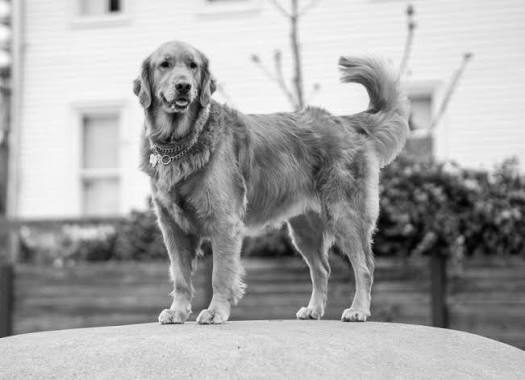

In [ ]:
grayimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(grayimg)
cv2.waitKey(0)
cv2.destroyAllWindows()

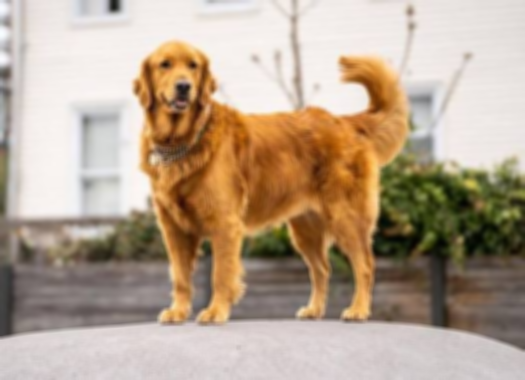

In [ ]:
import numpy as np

#inbuilt - avg filtering

average_filtered_img = cv2.blur(img, (5, 5))
cv2_imshow(average_filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


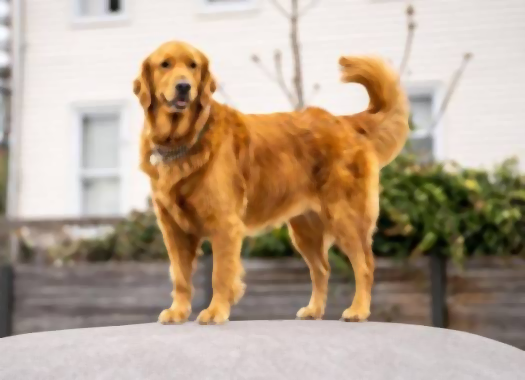

In [ ]:
#inbuilt - median filtering

median_filtered_img = cv2.medianBlur(img, 5)
cv2_imshow(median_filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

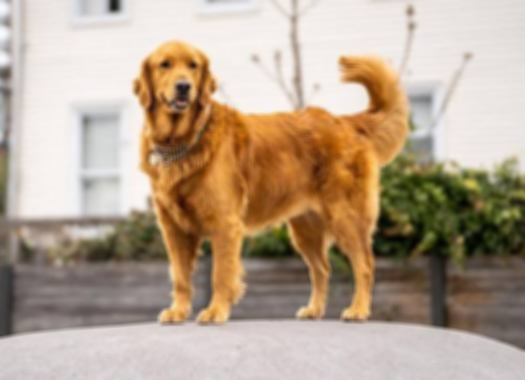

In [ ]:
def pad_image(image, kernel_size, pad_type='replicate'):
    """
    Pads the image to handle border effects during filtering.
    """
    pad_size = kernel_size // 2
    if image.ndim == 2:
        # Grayscale image
        return cv2.copyMakeBorder(image, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REPLICATE)
    elif image.ndim == 3:
        # Color image
        return cv2.copyMakeBorder(image, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REPLICATE)
    else:
        raise ValueError("Unsupported image dimensions")

def custom_average_filter(image, kernel_size):
    """
    Applies a custom low-pass average filter to the image.
    """
    padded_img = pad_image(image, kernel_size, pad_type='replicate')
    output_img = np.zeros_like(image, dtype=np.uint8)
    pad_size = kernel_size // 2

    if image.ndim == 2:
        h, w = image.shape
        for y in range(h):
            for x in range(w):
                region = padded_img[y:y + kernel_size, x:x + kernel_size]
                output_img[y, x] = np.mean(region)
    elif image.ndim == 3:
        h, w, c = image.shape
        for y in range(h):
            for x in range(w):
                for ch in range(c):
                    region = padded_img[y:y + kernel_size, x:x + kernel_size, ch]
                    output_img[y, x, ch] = np.mean(region)
    else:
        raise ValueError("Unsupported image dimensions")

    return output_img

def custom_median_filter(image, kernel_size):
    """
    Applies a custom low-pass median filter to the image.
    """
    padded_img = pad_image(image, kernel_size, pad_type='replicate')
    output_img = np.zeros_like(image, dtype=np.uint8)
    pad_size = kernel_size // 2

    if image.ndim == 2:
        h, w = image.shape
        for y in range(h):
            for x in range(w):
                region = padded_img[y:y + kernel_size, x:x + kernel_size]
                output_img[y, x] = np.median(region)
    elif image.ndim == 3:
        h, w, c = image.shape
        for y in range(h):
            for x in range(w):
                for ch in range(c):
                    region = padded_img[y:y + kernel_size, x:x + kernel_size, ch]
                    output_img[y, x, ch] = np.median(region)
    else:
        raise ValueError("Unsupported image dimensions")

    return output_img


KERNEL_SIZE = 5

# Apply custom average filter
custom_avg_filtered_img = custom_average_filter(img, KERNEL_SIZE)
cv2_imshow(custom_avg_filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


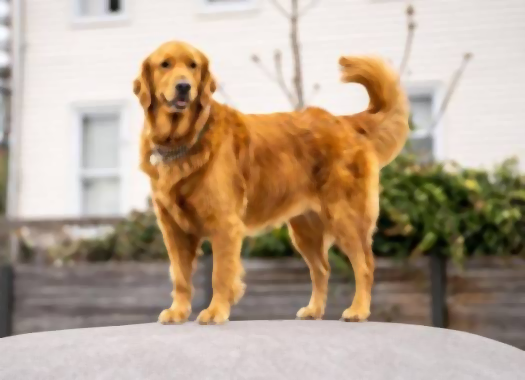

In [ ]:

custom_median_filtered_img = custom_median_filter(img, KERNEL_SIZE)
cv2_imshow(custom_median_filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


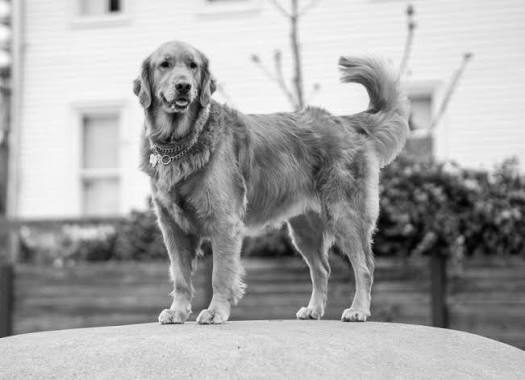

In [ ]:
#putting salt and pepper noise

snp_noise = img.copy();

snp_noise = cv2.cvtColor(snp_noise, cv2.COLOR_BGR2GRAY)
cv2_imshow(snp_noise)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import random
def add_noise(img):

    row , col = img.shape

    number_of_pixels = random.randint(300, 10000)
    for i in range(number_of_pixels):


        y_coord=random.randint(0, row - 1)

        x_coord=random.randint(0, col - 1)

        img[y_coord][x_coord] = 255


    number_of_pixels = random.randint(300 , 10000)
    for i in range(number_of_pixels):

        y_coord=random.randint(0, row - 1)

        x_coord=random.randint(0, col - 1)

        img[y_coord][x_coord] = 0

    return img

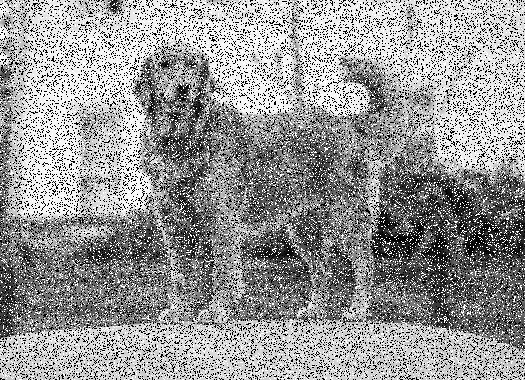

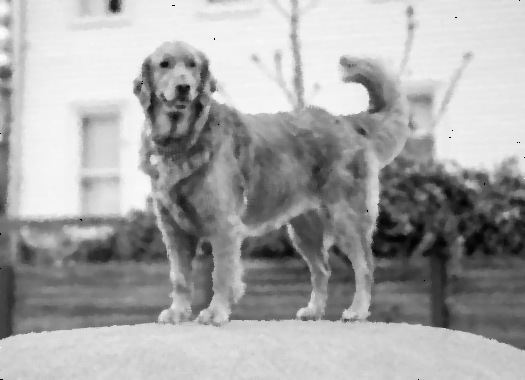

In [ ]:
snp_noise = add_noise(snp_noise)

cv2_imshow(snp_noise)
cv2.waitKey(0)
cv2.destroyAllWindows()
median_filtered_img = cv2.medianBlur(snp_noise, 5)
cv2_imshow(median_filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

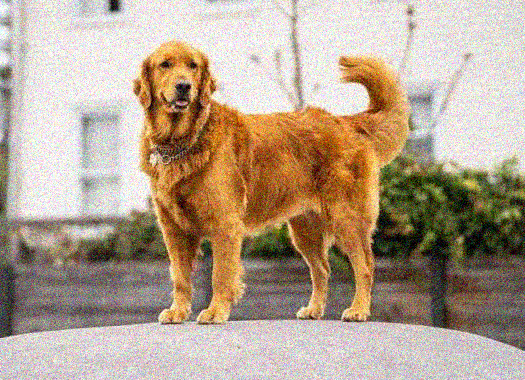

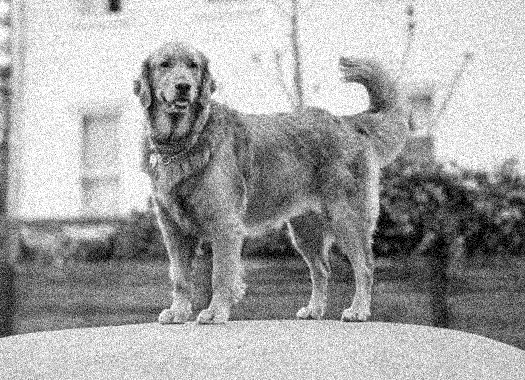

In [ ]:
import cv2
import numpy as np

def add_gaussian_noise(image, mean=0, sigma=25):


    gauss_noise = np.random.normal(mean, sigma, image.shape).astype('float32')

    noisy_image = image.astype('float32') + gauss_noise


    noisy_image = np.clip(noisy_image, 0, 255).astype('uint8')

    return noisy_image


normal = add_gausian_noise(img)
grey = add_gaussian_noise(snp_img)
